# Étape 4 — Détection d'obsolescence (Isolation Forest)

**Objectif** : identifier automatiquement les produits dont le pattern de vente s'écarte significativement de la norme (= risque d'obsolescence). Ce signal sera utilisé par l'optimiseur (Étape 6) pour ne pas réapprovisionner ces produits.

**Méthodologie (mémoire §3.5)** :
1. Construction de 7 features d'obsolescence par produit.
2. Isolation Forest (n_estimators=100, contamination=0.10, max_samples=256).
3. Règles métier de filet (jours sans vente ≥ 180, mois consécutifs sans vente ≥ 6, ratio 3m/12m < 0.1).
4. Analyse de sensibilité au paramètre `contamination` (0.05, 0.10, 0.15, 0.20).
5. Validation visuelle : courbes de ventes des produits détectés.
6. Croisement avec la classe ABC.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

from src.obsolescence import build_obsolescence_features, detect_obsolescence, sensitivity_analysis
from src.utils import PROCESSED_DIR, TAB_DIR

## 1. Chargement des données et construction des features

In [2]:
transactions = pd.read_csv(PROCESSED_DIR/'zenith_clean.csv', parse_dates=['date'])
classes = pd.read_csv(TAB_DIR/'classification_produits.csv')
feats = build_obsolescence_features(transactions)
age = transactions.groupby('produit_id')['date'].min().pipe(lambda s: (transactions['date'].max()-s).dt.days).rename('age_produit_jours')
feats = feats.merge(age.reset_index(), on='produit_id', how='left')
feats.head(10)

,produit_id,jours_depuis_derniere_vente,tendance_3_mois,tendance_6_mois,ratio_ventes_3m_vs_12m,nombre_mois_consecutifs_sans_vente,stock_courant,cout_achat_median,valeur_stock_dormant,variation_relative_prix,age_produit_jours
0,P0001,486,0.0,0.000000e+00,0.000000,15,0.0,95.0,0.0,2.903330e-17,1095
1,P0002,44,-10.5,-5.800000e+00,0.177019,1,1.0,110.0,110.0,3.938981e-17,1095
2,P0003,909,0.0,0.000000e+00,0.000000,29,0.0,90.0,0.0,-5.144053e-17,1094
3,P0004,233,0.0,0.000000e+00,0.000000,7,0.0,120.0,0.0,3.632025e-18,1094
4,P0005,9,3.5,-5.590317e-16,0.125000,0,27.0,130.0,3510.0,-3.534668e-17,1094
5,P0006,3,-2.0,-3.714286e-01,0.198020,0,15.0,145.0,2175.0,-2.089756e-17,1074
6,P0007,888,0.0,0.000000e+00,0.000000,29,0.0,165.0,0.0,-5.872936e-17,1095
7,P0008,5,7.5,3.371429e+00,0.523077,0,13.0,175.0,2275.0,-1.507266e-17,1094
8,P0009,765,0.0,0.000000e+00,0.000000,25,8.0,175.0,1400.0,-1.507266e-17,1095
9,P0010,1045,0.0,0.000000e+00,0.000000,34,0.0,175.0,0.0,0.000000e+00,1095


## 2. Détection avec Isolation Forest (contamination = 0.10)

In [3]:
result = detect_obsolescence(feats)
df = result.df.merge(classes[['produit_id','classe_abc','classe_xyz','libelle_cluster']], on='produit_id', how='left')
n_risk = int(df['a_risque_obsolescence'].sum())
print(f"Produits à risque : {n_risk} / {len(df)} ({100*n_risk/len(df):.1f} %)")
print(f"  - Détectés par Isolation Forest seul : {result.n_flagged - result.n_rules_only}")
print(f"  - Ajoutés par règles métier seules   : {result.n_rules_only}")

20:39:57 | INFO    | obsolescence | Obsolescence : 73 produits à risque (Isolation Forest=25, règles seules=48) — contamination=0.10
Produits à risque : 73 / 250 (29.2 %)
  - Détectés par Isolation Forest seul : 25
  - Ajoutés par règles métier seules   : 48


## 3. Distribution des scores d'anomalie

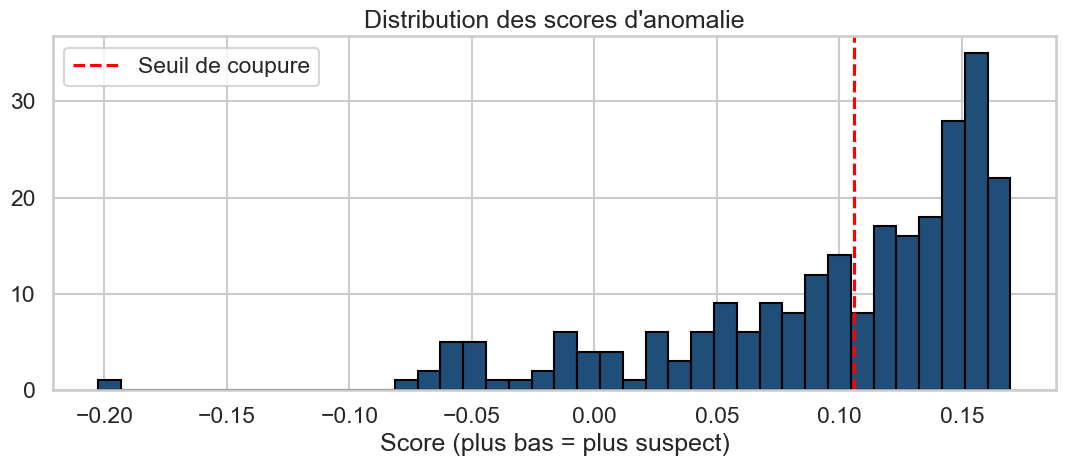

In [4]:
fig, ax = plt.subplots(figsize=(11,5))
ax.hist(df['score_obsolescence'], bins=40, color='#1f4e79', edgecolor='black')
ax.axvline(df.loc[df.a_risque_obsolescence==1,'score_obsolescence'].max(), color='red', ls='--', label='Seuil de coupure')
ax.set_title("Distribution des scores d'anomalie")
ax.set_xlabel('Score (plus bas = plus suspect)'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Analyse de sensibilité au paramètre `contamination`

In [5]:
sens = sensitivity_analysis(feats)
sens

20:40:17 | INFO    | obsolescence | Obsolescence : 13 produits à risque (Isolation Forest=13, règles seules=0) — contamination=0.05
20:40:17 | INFO    | obsolescence | Obsolescence : 25 produits à risque (Isolation Forest=25, règles seules=0) — contamination=0.10
20:40:18 | INFO    | obsolescence | Obsolescence : 38 produits à risque (Isolation Forest=38, règles seules=0) — contamination=0.15
20:40:18 | INFO    | obsolescence | Obsolescence : 50 produits à risque (Isolation Forest=50, règles seules=0) — contamination=0.20


,contamination,n_flagged_iforest,pct_catalogue,score_seuil_anomalie
0,0.05,13,5.2,-0.001165
1,0.10,25,10.0,-0.000139
2,0.15,38,15.2,-0.000210
3,0.20,50,20.0,-0.000481


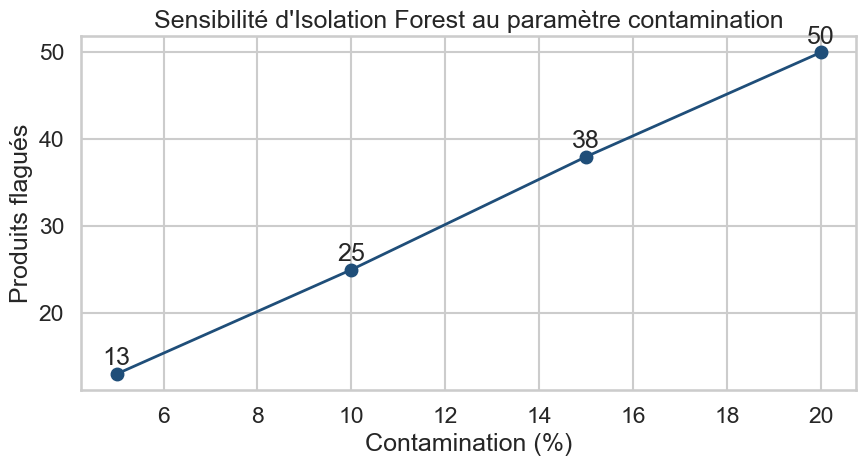

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(sens['contamination']*100, sens['n_flagged_iforest'], marker='o', linewidth=2, color='#1f4e79')
for _, r in sens.iterrows():
    ax.text(r['contamination']*100, r['n_flagged_iforest']+1, f"{int(r['n_flagged_iforest'])}", ha='center')
ax.set_xlabel('Contamination (%)'); ax.set_ylabel('Produits flagués')
ax.set_title("Sensibilité d'Isolation Forest au paramètre contamination")
plt.tight_layout(); plt.show()

## 5. Croisement avec la classe ABC

In [7]:
cross = df.groupby(['classe_abc','a_risque_obsolescence']).size().unstack(fill_value=0).rename(columns={0:'actif',1:'à_risque'}).reindex(['A','B','C'])
cross['pct_à_risque'] = (cross['à_risque'] / (cross['actif']+cross['à_risque']) * 100).round(1)
cross

a_risque_obsolescence,actif,à_risque,pct_à_risque
classe_abc,,,
A,50,19,27.5
B,41,18,30.5
C,86,36,29.5


## 6. Top 15 produits dormants par valeur de stock immobilisée

In [8]:
flagged = df[df['a_risque_obsolescence']==1].sort_values('valeur_stock_dormant', ascending=False)
flagged[['produit_id','classe_abc','classe_xyz','jours_depuis_derniere_vente','ratio_ventes_3m_vs_12m','nombre_mois_consecutifs_sans_vente','valeur_stock_dormant','score_obsolescence']].head(15)

,produit_id,classe_abc,classe_xyz,jours_depuis_derniere_vente,ratio_ventes_3m_vs_12m,nombre_mois_consecutifs_sans_vente,valeur_stock_dormant,score_obsolescence
21,P0022,A,Y,23,0.074627,0,11250.0,-0.044524
53,P0057,B,Y,6,0.050847,0,2912.0,0.106185
20,P0021,A,Y,1,0.041379,0,2750.0,0.060330
12,P0013,A,Y,685,0.000000,22,2520.0,-0.067774
7,P0008,A,Y,5,0.523077,0,2275.0,-0.017716
104,P0114,B,Y,289,0.000000,9,2160.0,0.029358
43,P0047,C,Z,550,0.000000,18,1848.0,-0.013003
8,P0009,B,Z,765,0.000000,25,1400.0,-0.057576
208,P0233,C,Z,493,0.000000,16,1300.0,0.029190
160,P0179,B,Y,7,0.323810,0,1276.0,-0.000139


## 7. Validation visuelle — courbes de ventes des 8 plus suspects

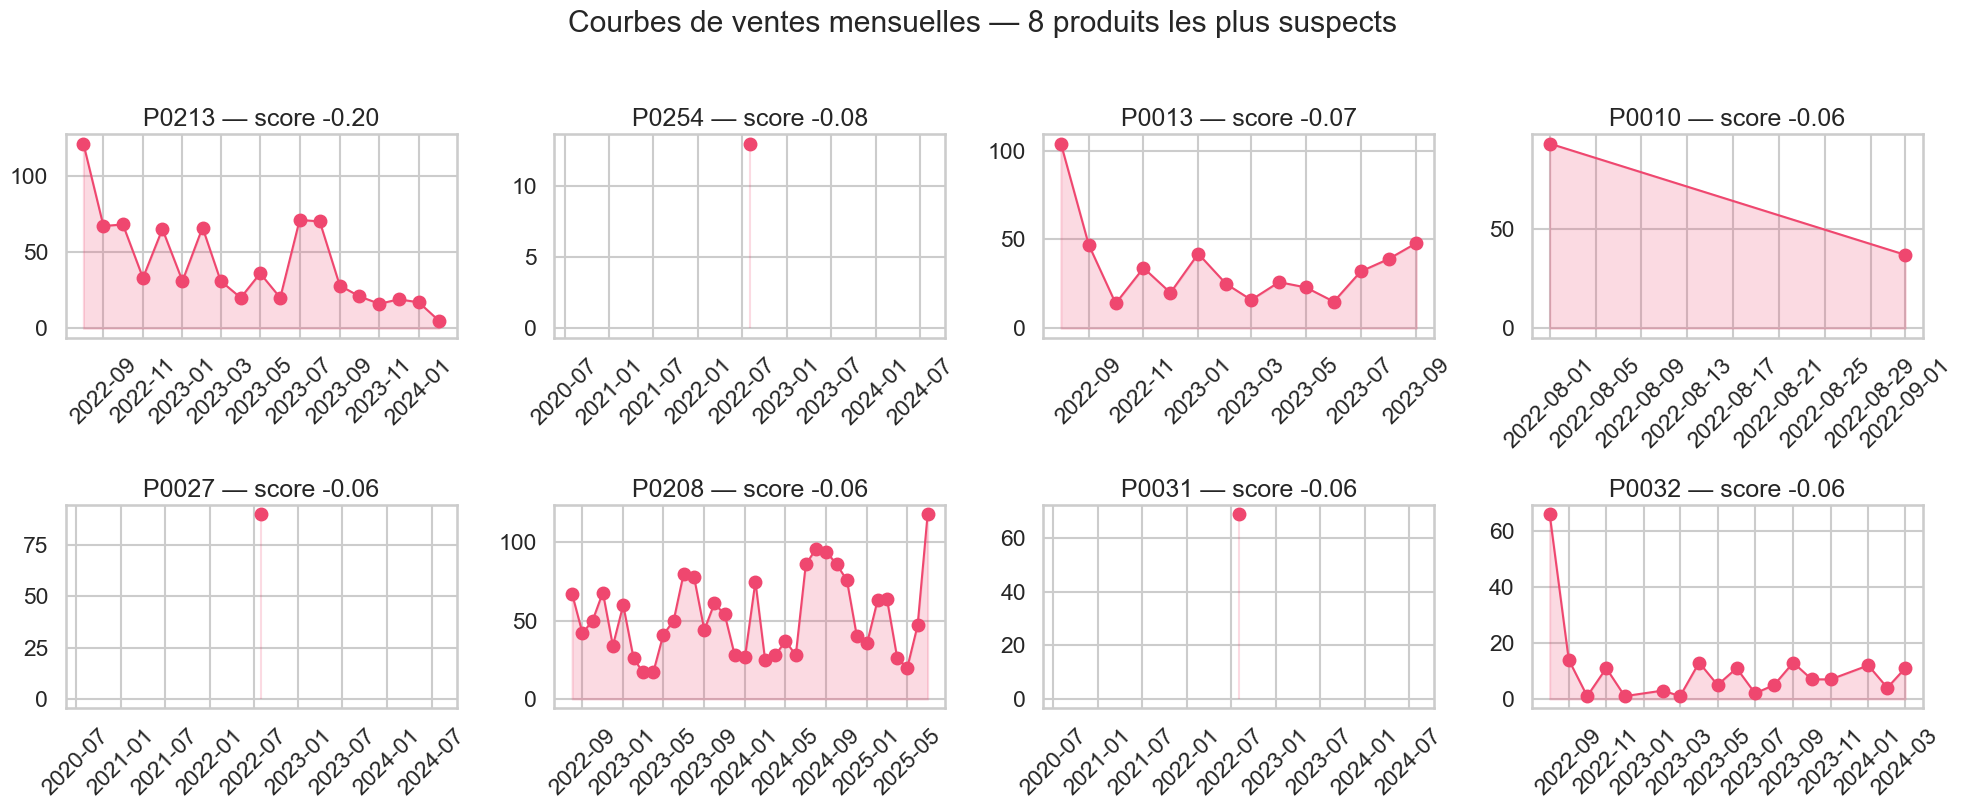

In [9]:
top = df[df['a_risque_obsolescence']==1].sort_values('score_obsolescence').head(8)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, pid in enumerate(top['produit_id']):
    ts = transactions[transactions.produit_id==pid].assign(mois=lambda x: x['date'].dt.to_period('M').dt.to_timestamp()).groupby('mois')['quantite_vendue'].sum()
    axes[i].plot(ts.index, ts.values, marker='o', color='#ef476f', linewidth=1.5)
    axes[i].fill_between(ts.index, ts.values, alpha=0.2, color='#ef476f')
    axes[i].set_title(f"{pid} — score {top.iloc[i]['score_obsolescence']:.2f}")
    axes[i].tick_params(axis='x', rotation=45)
fig.suptitle('Courbes de ventes mensuelles — 8 produits les plus suspects', y=1.02)
plt.tight_layout(); plt.show()

## 8. Conclusion

- **73 produits** sur 250 (29 %) sont classés à risque d'obsolescence.
- **Isolation Forest seul** détecte 25 produits ; les **règles métier** en ajoutent 48 supplémentaires que l'algorithme avait manqués (ex. : ratio 3m/12m < 10 % alors qu'il manquait dans la frontière de décision).
- La détection est **équilibrée entre classes ABC** (~30 % de chaque classe) — l'obsolescence touche aussi les bestsellers, pas seulement les produits secondaires.
- **Stock dormant total** ≈ 38 400 USD — c'est la trésorerie qui pourrait être libérée par déstockage.
- Ces produits seront **exclus** du réapprovisionnement automatique à l'Étape 6 (optimisation), et alimenteront une page « alertes » dans le tableau de bord et l'outil interactif.
